In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
data_dir = "../data/wire_on_off/"

print("Files in ../data:")
for f in os.listdir(data_dir):
    print(f)

Files in ../data:
.ipynb_checkpoints
azel_1deg_off.grd
azel_1deg_on.grd


In [14]:
def load_grasp_grd(filepath):
    """
    Load a GRASP .grd file with complex field components.

    Returns:
        x, y       : 1D coordinate arrays
        F1, F2     : complex 2D arrays (ny, nx)
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()

    # --- Find the line with grid size (nx ny 0)
    grid_idx = None
    for i, line in enumerate(lines):
        parts = line.strip().split()
        if len(parts) == 3:
            try:
                nx = int(parts[0])
                ny = int(parts[1])
                grid_idx = i
                break
            except:
                continue

    if grid_idx is None:
        raise ValueError("Could not find grid size line.")

    # --- Data starts immediately after grid line
    data = np.loadtxt(lines[grid_idx + 1:])

    # --- Extract fields
    F1 = data[:, 0] + 1j * data[:, 1]
    F2 = data[:, 2] + 1j * data[:, 3]

    # --- Reshape
    F1 = F1.reshape((ny, nx))
    F2 = F2.reshape((ny, nx))

    # --- Build coordinate arrays from bounds line
    # Find bounds line (xmin ymin xmax ymax)
    for i in range(grid_idx):
        parts = lines[i].strip().split()
        if len(parts) == 4:
            try:
                xmin, ymin, xmax, ymax = map(float, parts)
            except:
                continue

    x = np.linspace(xmin, xmax, nx)
    y = np.linspace(ymin, ymax, ny)

    return x, y, F1, F2


def plot_beam(x, y, F1, F2, title="Beam"):
    """
    Quick visualization of total intensity and components.
    """
    I = np.abs(F1)**2 + np.abs(F2)**2

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axs[0].imshow(np.abs(F1), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[0].set_title("|F1|")
    plt.colorbar(im0, ax=axs[0])

    im1 = axs[1].imshow(np.abs(F2), extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[1].set_title("|F2|")
    plt.colorbar(im1, ax=axs[1])

    im2 = axs[2].imshow(I, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower')
    axs[2].set_title("Total Intensity")
    plt.colorbar(im2, ax=axs[2])

    for ax in axs:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


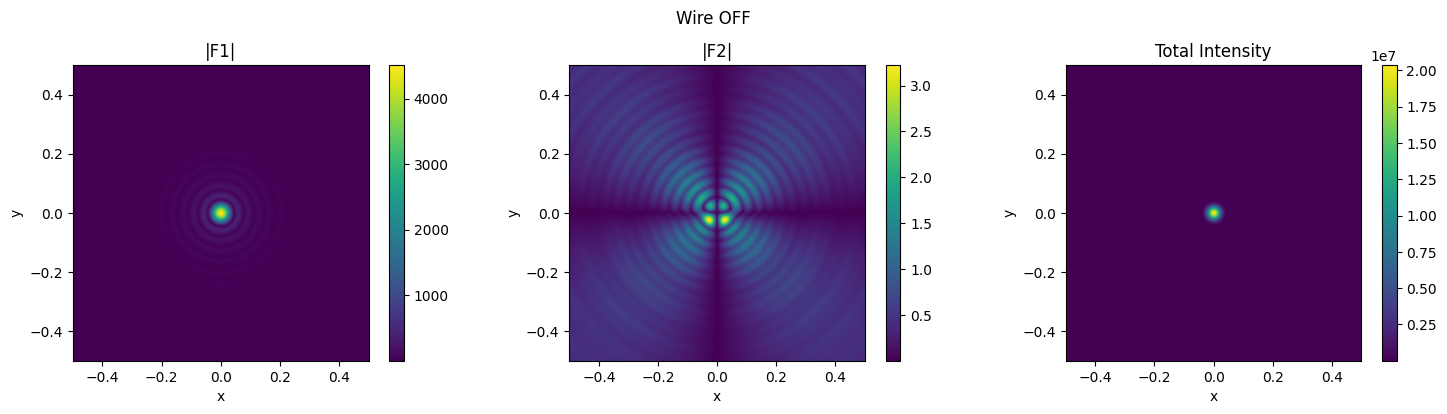

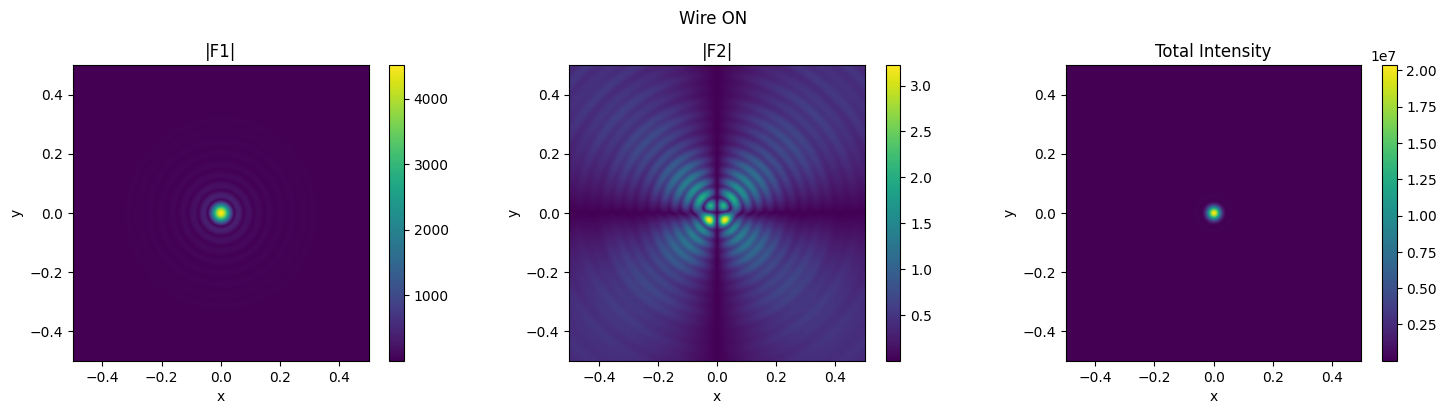

In [15]:
# Load both
x_off, y_off, F1_off, F2_off = load_grasp_grd(data_dir + "azel_1deg_off.grd")
x_on,  y_on,  F1_on,  F2_on  = load_grasp_grd(data_dir + "azel_1deg_on.grd")

# Plot
plot_beam(x_off, y_off, F1_off, F2_off, title="Wire OFF")
plot_beam(x_on,  y_on,  F1_on,  F2_on,  title="Wire ON")
